## 0. Import thư viện và helper functions

In [1]:
%matplotlib inline

from pathlib import Path
import warnings
import ssl
import re
from html import unescape
from urllib.parse import urlencode
from urllib.request import urlopen

try:
    import requests
except ModuleNotFoundError:
    requests = None

try:
    import certifi
    DRIVE_SSL_CONTEXT = ssl.create_default_context(cafile=certifi.where())
except ModuleNotFoundError:
    DRIVE_SSL_CONTEXT = ssl._create_unverified_context()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110

COLOR_MAIN = "#2563EB"
COLOR_ACCENT = "#F97316"
COLOR_DARK = "#0F172A"

def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom))


def regression_metrics(model_name, split_name, y_true, y_pred):
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

    y_true = np.asarray(y_true)
    y_pred = np.clip(np.asarray(y_pred), 0, None)
    return {
        "model": model_name,
        "split": split_name,
        "rows": len(y_true),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "WAPE": wape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "bias": np.mean(y_pred - y_true),
        "actual_sum": np.sum(y_true),
        "pred_sum": np.sum(y_pred),
    }

def show_df(data, n=5):
    """Display the first n rows in notebook output."""
    display(data.head(n))


## 1. Load dữ liệu

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TARGET_COL = "revenue"
KEY_COLS = ["date", "store_id", "product_type"]


def get_drive_file_id(drive_link):
    match = re.search(r"/d/([a-zA-Z0-9_-]+)|id=([a-zA-Z0-9_-]+)", drive_link)

    if not match:
        raise ValueError("Google Drive link is not valid.")

    return match.group(1) or match.group(2)


def read_csv_from_google_drive(drive_link, **read_csv_kwargs):
    file_id = get_drive_file_id(drive_link)
    base_url = "https://drive.google.com/uc"
    params = {
        "export": "download",
        "id": file_id,
    }

    if requests is not None:
        session = requests.Session()
        response = session.get(base_url, params=params, stream=True)
        response.raise_for_status()

        if "text/html" in response.headers.get("Content-Type", ""):
            html = response.text

            form_action = re.search(r'<form[^>]+action="([^"]+)"', html)
            if not form_action:
                raise RuntimeError(
                    "Cannot get download link. Please check Google Drive sharing permission."
                )

            download_url = unescape(form_action.group(1))

            hidden_inputs = re.findall(
                r'<input[^>]+type="hidden"[^>]+name="([^"]+)"[^>]+value="([^"]*)"',
                html,
            )

            download_params = dict(hidden_inputs)

            response = session.get(download_url, params=download_params, stream=True)
            response.raise_for_status()

            if "text/html" in response.headers.get("Content-Type", ""):
                raise RuntimeError(
                    "Google Drive still returned HTML instead of CSV. "
                    "Please check file permission or try again later."
                )

        response.raw.decode_content = True
        return pd.read_csv(response.raw, **read_csv_kwargs)

    # Fallback khi môi trường notebook chưa cài requests.
    response = urlopen(f"{base_url}?{urlencode(params)}", context=DRIVE_SSL_CONTEXT)
    content_type = response.headers.get("Content-Type", "")

    if "text/html" in content_type:
        html = response.read().decode("utf-8", errors="replace")

        form_action = re.search(r'<form[^>]+action="([^"]+)"', html)
        if not form_action:
            raise RuntimeError(
                "Cannot get download link. Please check Google Drive sharing permission."
            )

        download_url = unescape(form_action.group(1))
        hidden_inputs = re.findall(
            r'<input[^>]+type="hidden"[^>]+name="([^"]+)"[^>]+value="([^"]*)"',
            html,
        )
        download_params = dict(hidden_inputs)
        response = urlopen(f"{download_url}?{urlencode(download_params)}", context=DRIVE_SSL_CONTEXT)

        if "text/html" in response.headers.get("Content-Type", ""):
            raise RuntimeError(
                "Google Drive still returned HTML instead of CSV. "
                "Please check file permission or try again later."
            )

    return pd.read_csv(response, **read_csv_kwargs)


drive_link = "https://drive.google.com/file/d/1fpfiLN9yxAlWRHmHRN7UCBhDpMgd8R8P/view?usp=drive_link"

df_raw = read_csv_from_google_drive(drive_link, low_memory=False)
df_drive = df_raw.copy()
df_drive["transaction_date"] = pd.to_datetime(df_drive["transaction_date"])
df_drive["first_opened_date"] = pd.to_datetime(df_drive["first_opened_date"])
df_drive["last_remodel_date"] = pd.to_datetime(df_drive["last_remodel_date"])

print("Shape:", df_drive.shape)
print("Date range:", df_drive["transaction_date"].min().date(), "->", df_drive["transaction_date"].max().date())
print("Stores:", df_drive["store_id"].nunique())
print("Product types:", df_drive["product_type"].nunique())
print(
    "Rows are unique by store-date-product:",
    not df_drive.duplicated(["transaction_date", "store_id", "product_type"]).any(),
)

show_df(df_drive, 5)

# Chuẩn hóa tên cột ngày để các cell phân tích/model phía sau dùng cùng schema nội bộ.
df = df_drive.rename(columns={"transaction_date": "date"}).copy()

dataset_overview = pd.DataFrame([
    {"metric": "source_file", "value": drive_link},
    {"metric": "rows", "value": len(df)},
    {"metric": "columns", "value": df.shape[1]},
    {"metric": "min_date", "value": df["date"].min().date()},
    {"metric": "max_date", "value": df["date"].max().date()},
    {"metric": "unique_dates", "value": df["date"].nunique()},
    {"metric": "unique_store_dates", "value": df[["date", "store_id"]].drop_duplicates().shape[0]},
    {"metric": "unique_stores", "value": df["store_id"].nunique()},
    {"metric": "unique_product_types", "value": df["product_type"].nunique()},
])

display(dataset_overview)

Shape: (22476, 47)
Date range: 1997-01-01 -> 1998-12-30
Stores: 13
Product types: 16
Rows are unique by store-date-product: True


,transaction_date,store_id,product_type,revenue,quantity_sold,transaction_rows,unique_products,unique_brands,unique_customers,recyclable_share,low_fat_share,region_id,store_type,store_city,store_state,first_opened_date,last_remodel_date,total_sqft,grocery_sqft,sales_district,sales_region,weather_code,temperature_mean_c,precipitation_mm,snowfall_cm,wind_speed_max_kmh,shortwave_radiation_mj_m2,year,month,quarter,day,day_of_week,day_of_week_num,week_of_year,is_weekend,weighted_avg_retail_price,weighted_avg_product_cost,weighted_avg_product_weight,store_age_years,years_since_remodel,grocery_sqft_ratio,is_rainy_day,is_snowy_day,is_windy_day,avg_revenue_per_customer,avg_revenue_per_product,avg_revenue_per_transaction_row
0,1997-01-01,6,Bakery,21.7400,11,4,4,3,4,0.7500,0.0000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,1.9764,0.8800,17.2455,15.9945,5.8070,0.6475,1,0,0,5.4350,5.4350,5.4350
1,1997-01-01,6,Beverages,66.7800,32,9,9,7,8,0.7778,0.1111,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,2.0869,0.8191,13.1612,15.9945,5.8070,0.6475,1,0,0,8.3475,7.4200,7.4200
2,1997-01-01,6,Breakfast Foods,11.6400,4,1,1,1,1,1.0000,0.0000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,2.9100,0.9900,21.8000,15.9945,5.8070,0.6475,1,0,0,11.6400,11.6400,11.6400
3,1997-01-01,6,Canned & Soup,7.0900,7,2,2,2,2,1.0000,1.0000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,1.0129,0.4657,11.0914,15.9945,5.8070,0.6475,1,0,0,3.5450,3.5450,3.5450
4,1997-01-01,6,Dairy & Eggs,58.2400,22,6,6,5,5,0.6667,0.5000,47,Gourmet Supermarket,Beverly Hills,CA,1981-01-03,1991-03-13,23688,15337,Los Angeles,South West,51,14.9000,0.1000,0.0000,7.9000,4.1400,1997,1,1,1,Wednesday,2,1,0,2.6473,1.0982,14.3123,15.9945,5.8070,0.6475,1,0,0,11.6480,9.7067,9.7067


,metric,value
0,source_file,https://drive.google.com/file/d/1fpfiLN9yxAlWR...
1,rows,22476
2,columns,47
3,min_date,1997-01-01
4,max_date,1998-12-30
5,unique_dates,649
6,unique_store_dates,1560
7,unique_stores,13
8,unique_product_types,16


**Đọc output thật**

Dataset gốc có **22,476 dòng và 47 cột**, bao phủ từ **1997-01-01 đến 1998-12-30**. Mỗi dòng là doanh thu của một `product_type` trong một `store_id` tại một ngày giao dịch. Có **13 cửa hàng**, **16 nhóm sản phẩm** và **1,560 store-date** quan sát được.

## 2. Schema, key và leakage

In [3]:
column_profile = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing": [int(df[c].isna().sum()) for c in df.columns],
    "missing_pct": [df[c].isna().mean() for c in df.columns],
    "nunique": [int(df[c].nunique(dropna=True)) for c in df.columns],
})

duplicate_keys = df.duplicated(KEY_COLS).sum()

leakage_review = pd.DataFrame([
    {"column": "quantity_sold", "decision": "EDA only", "reason": "Số lượng bán ra phát sinh trong ngày; dùng làm feature sẽ gần như tiết lộ doanh thu."},
    {"column": "transaction_rows", "decision": "EDA only", "reason": "Số dòng giao dịch là kết quả trong ngày cần dự báo."},
    {"column": "unique_products / unique_brands / unique_customers", "decision": "EDA only", "reason": "Đều chỉ biết sau khi ngày bán hàng xảy ra."},
    {"column": "weighted_avg_retail_price / product_cost / product_weight", "decision": "Không dùng trong clean model", "reason": "Là trung bình có trọng số theo mix sản phẩm đã bán trong ngày; có rủi ro leakage/sales-mix leakage."},
    {"column": "avg_revenue_per_customer / product / transaction_row", "decision": "Loại khỏi model", "reason": "Được tính trực tiếp từ target revenue."},
    {"column": "calendar, store metadata, weather", "decision": "Có thể dùng", "reason": "Biết trước hoặc có thể lấy từ nguồn ngoại sinh khi dự báo."},
])

key_summary = pd.DataFrame([
    {"check": "key_cols", "value": ", ".join(KEY_COLS)},
    {"check": "duplicate_keys", "value": int(duplicate_keys)},
    {"check": "target_col", "value": TARGET_COL},
    {"check": "negative_revenue_rows", "value": int((df[TARGET_COL] < 0).sum())},
    {"check": "zero_revenue_rows_in_raw", "value": int((df[TARGET_COL] == 0).sum())},
])

display(key_summary)
display(column_profile)
display(leakage_review)

,check,value
0,key_cols,"date, store_id, product_type"
1,duplicate_keys,0
2,target_col,revenue
3,negative_revenue_rows,0
4,zero_revenue_rows_in_raw,0


,column,dtype,missing,missing_pct,nunique
0,date,datetime64[ns],0,0.0000,649
1,store_id,int64,0,0.0000,13
2,product_type,object,0,0.0000,16
3,revenue,float64,0,0.0000,11255
4,quantity_sold,int64,0,0.0000,171
5,transaction_rows,int64,0,0.0000,71
6,unique_products,int64,0,0.0000,62
7,unique_brands,int64,0,0.0000,17
8,unique_customers,int64,0,0.0000,58
9,recyclable_share,float64,0,0.0000,278


,column,decision,reason
0,quantity_sold,EDA only,Số lượng bán ra phát sinh trong ngày; dùng làm...
1,transaction_rows,EDA only,Số dòng giao dịch là kết quả trong ngày cần dự...
2,unique_products / unique_brands / unique_custo...,EDA only,Đều chỉ biết sau khi ngày bán hàng xảy ra.
3,weighted_avg_retail_price / product_cost / pro...,Không dùng trong clean model,Là trung bình có trọng số theo mix sản phẩm đã...
4,avg_revenue_per_customer / product / transacti...,Loại khỏi model,Được tính trực tiếp từ target revenue.
5,"calendar, store metadata, weather",Có thể dùng,Biết trước hoặc có thể lấy từ nguồn ngoại sinh...


**Leakage decision**

Key tự nhiên là `date × store_id × product_type` và không có duplicate. Dữ liệu gốc không có missing và không có doanh thu âm. Tuy nhiên nhiều cột như `quantity_sold`, `transaction_rows`, `unique_customers`, `avg_revenue_per_customer` là thông tin sau bán hàng, nên chỉ dùng để đọc hiểu business chứ không đưa vào mô hình forecasting sạch.

## 3. Data quality và observed coverage

In [4]:
observed_store_dates = df[["date", "store_id"]].drop_duplicates()
product_count_per_store_date = df.groupby(["date", "store_id"])["product_type"].nunique()

quality_summary = pd.DataFrame([
    {"metric": "rows", "value": len(df)},
    {"metric": "columns", "value": df.shape[1]},
    {"metric": "duplicate_keys", "value": int(df.duplicated(KEY_COLS).sum())},
    {"metric": "missing_values", "value": int(df.isna().sum().sum())},
    {"metric": "zero_revenue_rows", "value": int((df["revenue"] == 0).sum())},
    {"metric": "negative_revenue_rows", "value": int((df["revenue"] < 0).sum())},
    {"metric": "observed_store_dates", "value": len(observed_store_dates)},
    {"metric": "unique_product_types", "value": df["product_type"].nunique()},
    {"metric": "median_product_types_per_store_date", "value": product_count_per_store_date.median()},
    {"metric": "min_product_types_per_store_date", "value": product_count_per_store_date.min()},
    {"metric": "max_product_types_per_store_date", "value": product_count_per_store_date.max()},
])

display(quality_summary)
display(product_count_per_store_date.describe().to_frame("product_type_count").T)


,metric,value
0,rows,"22,476.0000"
1,columns,47.0000
2,duplicate_keys,0.0000
3,missing_values,0.0000
4,zero_revenue_rows,0.0000
5,negative_revenue_rows,0.0000
6,observed_store_dates,"1,560.0000"
7,unique_product_types,16.0000
8,median_product_types_per_store_date,16.0000
9,min_product_types_per_store_date,5.0000


,count,mean,std,min,25%,50%,75%,max
product_type_count,"1,560.0000",14.4077,2.3186,5.0000,14.0000,16.0000,16.0000,16.0000


**Đọc output thật**

Dữ liệu dùng cho bài toán observed-only có **22,476 dòng**, không duplicate theo key `date × store_id × product_type`, không missing, không doanh thu âm và không có dòng doanh thu bằng 0. Dataset có **1,560 observed store-date** và **16 product_type**; mỗi store-date ghi nhận từ 5 đến 16 nhóm sản phẩm, median là 16.

## 4. Target distribution và outlier

,observed_revenue
count,"22,476.0000"
mean,52.4092
std,51.4020
min,0.5000
1%,1.3175
5%,3.0600
25%,13.6275
50%,36.7000
75%,76.2000
95%,152.9225


,metric,value
0,iqr_upper_bound,170.0588
1,outlier_rows_observed,736.0000
2,outlier_pct_observed,0.0327
3,max_revenue,706.4500


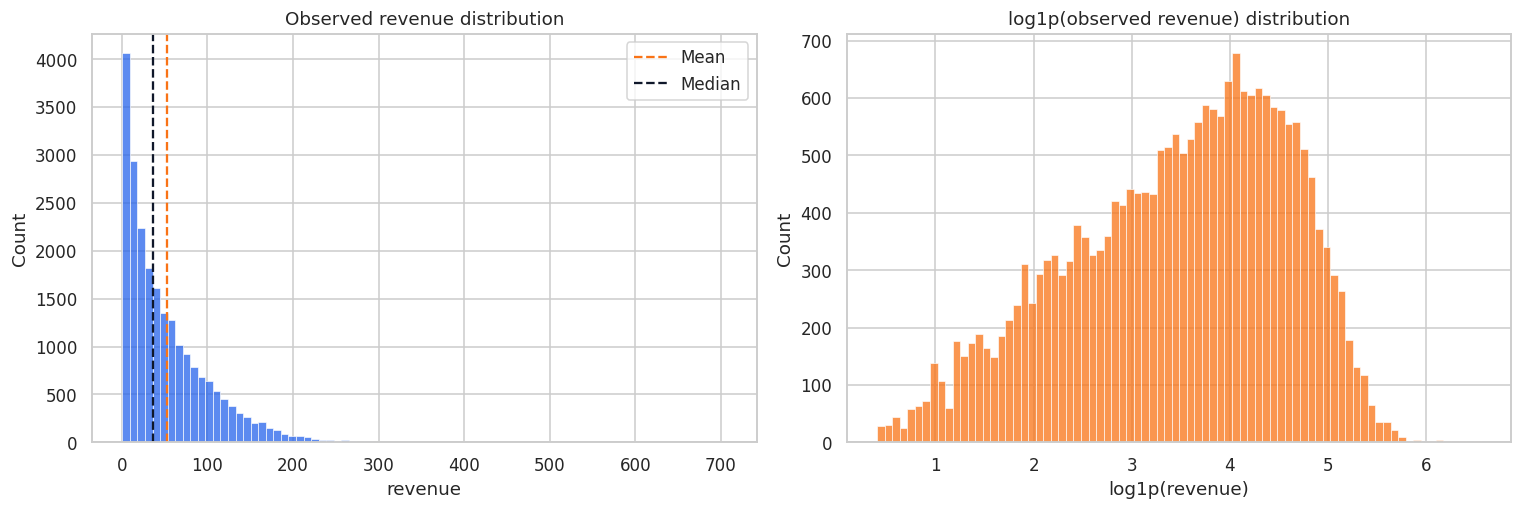

In [5]:
analysis_df = df.copy().sort_values(["store_id", "product_type", "date"]).reset_index(drop=True)

q1 = analysis_df[TARGET_COL].quantile(0.25)
q3 = analysis_df[TARGET_COL].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

observed_target_summary = analysis_df[TARGET_COL].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("observed_revenue")
outlier_summary = pd.DataFrame([
    {"metric": "iqr_upper_bound", "value": upper_bound},
    {"metric": "outlier_rows_observed", "value": int((analysis_df[TARGET_COL] > upper_bound).sum())},
    {"metric": "outlier_pct_observed", "value": (analysis_df[TARGET_COL] > upper_bound).mean()},
    {"metric": "max_revenue", "value": analysis_df[TARGET_COL].max()},
])

display(observed_target_summary)
display(outlier_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.histplot(analysis_df[TARGET_COL], bins=80, color=COLOR_MAIN, ax=axes[0])
axes[0].axvline(analysis_df[TARGET_COL].mean(), color=COLOR_ACCENT, linestyle="--", label="Mean")
axes[0].axvline(analysis_df[TARGET_COL].median(), color=COLOR_DARK, linestyle="--", label="Median")
axes[0].set_title("Observed revenue distribution")
axes[0].legend()

sns.histplot(np.log1p(analysis_df[TARGET_COL]), bins=80, color=COLOR_ACCENT, ax=axes[1])
axes[1].set_title("log1p(observed revenue) distribution")
axes[1].set_xlabel("log1p(revenue)")
plt.tight_layout()
plt.show()

**Insight target**

Doanh thu quan sát được lệch phải rõ rệt: mean cao hơn median và có một nhóm doanh thu cao ở các product type lớn như `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning`. Vì notebook chỉ dùng dòng được ghi nhận, kết quả mô hình nên được hiểu là dự báo **doanh thu conditional on product_type-store-date đã xuất hiện trong dữ liệu**, không phải dự báo xác suất một nhóm sản phẩm có bán hay không.

## 5. Revenue by product_type, store và store-product

,raw_rows,total_revenue,mean_revenue_observed,median_revenue_observed,total_quantity,revenue_share_pct
product_type,,,,,,
Produce & Nuts,1542,"169,819.1600",110.1300,113.9000,78338,14.4200
Snacks & Sweets,1540,"151,010.6500",98.0600,101.3200,69090,12.8200
Household & Cleaning,1526,"137,072.2200",89.8200,91.3800,61996,11.6400
Frozen Foods,1516,"115,666.2900",76.3000,76.6500,55721,9.8200
Dairy & Eggs,1505,"93,070.2100",61.8400,59.6000,42156,7.9000
Pantry & Condiments,1501,"82,176.1500",54.7500,53.1100,42938,6.9800
Beverages,1484,"78,394.2800",52.8300,50.9900,37615,6.6600
Meat & Deli,1465,"64,749.3800",44.2000,41.6200,30539,5.5000
Canned & Soup,1458,"62,534.7800",42.8900,41.6800,30622,5.3100


,,,,raw_rows,total_revenue,mean_revenue_observed,revenue_share_pct
store_id,store_type,store_city,store_state,,,,
13,Deluxe Supermarket,Salem,OR,1893,"170,398.9400",90.0200,14.4700
17,Deluxe Supermarket,Tacoma,WA,1900,"157,695.9000",83.0000,13.3900
15,Supermarket,Seattle,WA,1881,"115,981.4600",61.6600,9.8500
11,Supermarket,Portland,OR,1883,"115,334.6200",61.2500,9.7900
24,Supermarket,San Diego,CA,1872,"111,378.4600",59.5000,9.4600
7,Supermarket,Los Angeles,CA,1899,"111,309.1400",58.6100,9.4500
3,Supermarket,Bremerton,WA,1863,"110,877.8800",59.5200,9.4100
16,Supermarket,Spokane,WA,1870,"110,480.0600",59.0800,9.3800
6,Gourmet Supermarket,Beverly Hills,CA,1861,"98,114.7800",52.7200,8.3300


,,,,total_revenue,mean_revenue,rows,revenue_share_pct
store_id,store_city,store_state,product_type,,,,
13,Salem,OR,Produce & Nuts,"25,207.1200",210.0600,120,2.1400
17,Tacoma,WA,Produce & Nuts,"22,767.0000",189.7200,120,1.9300
13,Salem,OR,Snacks & Sweets,"21,788.3700",181.5700,120,1.8500
17,Tacoma,WA,Snacks & Sweets,"20,299.2600",169.1600,120,1.7200
13,Salem,OR,Household & Cleaning,"19,960.9300",166.3400,120,1.6900
17,Tacoma,WA,Household & Cleaning,"18,326.7900",152.7200,120,1.5600
13,Salem,OR,Frozen Foods,"16,942.2900",141.1900,120,1.4400
11,Portland,OR,Produce & Nuts,"16,810.6300",140.0900,120,1.4300
15,Seattle,WA,Produce & Nuts,"16,265.0700",135.5400,120,1.3800


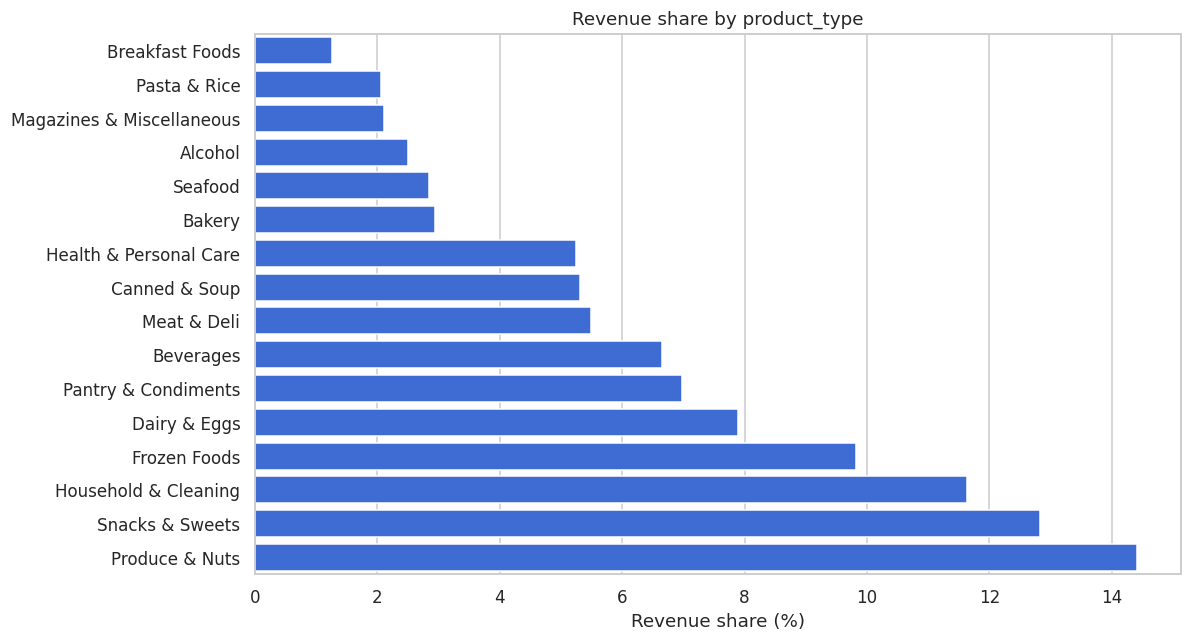

In [20]:
product_summary = (
    df.groupby("product_type")
    .agg(
        raw_rows=("revenue", "size"),
        total_revenue=("revenue", "sum"),
        mean_revenue_observed=("revenue", "mean"),
        median_revenue_observed=("revenue", "median"),
        total_quantity=("quantity_sold", "sum"),
    )
    .assign(revenue_share_pct=lambda x: x["total_revenue"] / x["total_revenue"].sum() * 100)
    .sort_values("total_revenue", ascending=False)
)

store_summary = (
    df.groupby(["store_id", "store_type", "store_city", "store_state"])
    .agg(raw_rows=("revenue", "size"), total_revenue=("revenue", "sum"), mean_revenue_observed=("revenue", "mean"))
    .assign(revenue_share_pct=lambda x: x["total_revenue"] / x["total_revenue"].sum() * 100)
    .sort_values("total_revenue", ascending=False)
)

store_product_top = (
    df.groupby(["store_id", "store_city", "store_state", "product_type"])
    .agg(total_revenue=("revenue", "sum"), mean_revenue=("revenue", "mean"), rows=("revenue", "size"))
    .assign(revenue_share_pct=lambda x: x["total_revenue"] / df["revenue"].sum() * 100)
    .sort_values("total_revenue", ascending=False)
    .head(15)
)

display(product_summary.round(2))
display(store_summary.round(2))
display(store_product_top.round(2))

plt.figure(figsize=(11, 6))
plot_df = product_summary.reset_index().sort_values("total_revenue", ascending=True)
sns.barplot(data=plot_df, y="product_type", x="revenue_share_pct", color=COLOR_MAIN)
plt.title("Revenue share by product_type")
plt.xlabel("Revenue share (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Insight product/store**

Doanh thu tập trung theo nhóm sản phẩm: `Produce & Nuts` đứng đầu khoảng **14.4%**, kế đến `Snacks & Sweets` khoảng **12.8%** và `Household & Cleaning` khoảng **11.6%**. Về cửa hàng, `store_id=13` Salem và `store_id=17` Tacoma là hai store lớn nhất, lần lượt khoảng **14.5%** và **13.4%** tổng doanh thu. Model cần học cả scale của `product_type` lẫn baseline riêng của từng store.

## 6. Time trend, seasonality và day-of-week

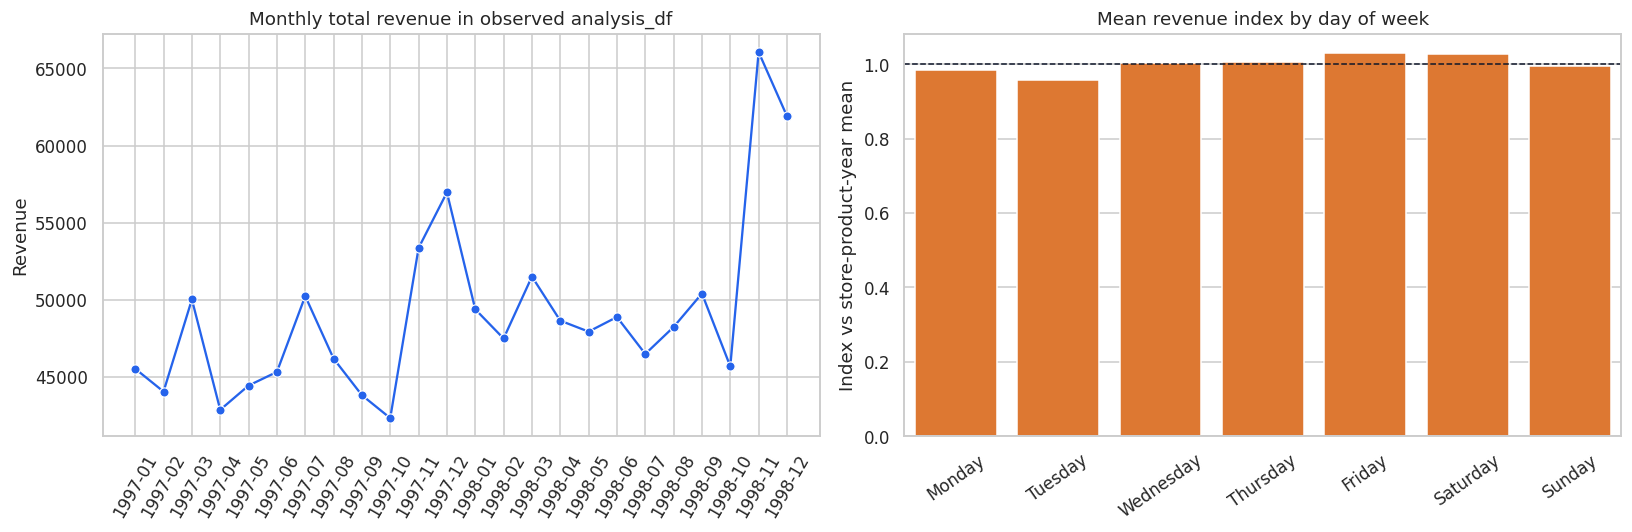

In [21]:
base_revenue = analysis_df.groupby(["store_id", "product_type", "year"])[TARGET_COL].transform("mean").replace(0, np.nan)
analysis_df["revenue_index"] = analysis_df[TARGET_COL] / base_revenue

monthly_summary = (
    analysis_df.groupby(["year", "month"], as_index=False)
    .agg(total_revenue=(TARGET_COL, "sum"), mean_revenue=(TARGET_COL, "mean"), store_dates=("date", "nunique"))
)

dow_summary = (
    analysis_df.groupby(["day_of_week", "day_of_week_num"], as_index=False)
    .agg(mean_revenue=(TARGET_COL, "mean"), median_revenue=(TARGET_COL, "median"), mean_index=("revenue_index", "mean"), rows=(TARGET_COL, "size"))
    .sort_values("day_of_week_num")
)

product_month = (
    analysis_df.groupby(["product_type", "month"], as_index=False)
    .agg(mean_revenue=(TARGET_COL, "mean"), mean_index=("revenue_index", "mean"))
)

peak_month_by_product = product_month.loc[product_month.groupby("product_type")["mean_revenue"].idxmax()].sort_values("mean_revenue", ascending=False)

# display(monthly_summary.round(3))
# display(dow_summary.round(3))
# display(peak_month_by_product.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
month_plot = monthly_summary.assign(month_period=lambda x: x["year"].astype(str) + "-" + x["month"].astype(str).str.zfill(2))
sns.lineplot(data=month_plot, x="month_period", y="total_revenue", marker="o", color=COLOR_MAIN, ax=axes[0])
axes[0].tick_params(axis="x", rotation=60)
axes[0].set_title("Monthly total revenue in observed analysis_df")
axes[0].set_xlabel("")
axes[0].set_ylabel("Revenue")

sns.barplot(data=dow_summary, x="day_of_week", y="mean_index", color=COLOR_ACCENT, ax=axes[1])
axes[1].axhline(1.0, color=COLOR_DARK, linestyle="--", linewidth=1)
axes[1].tick_params(axis="x", rotation=35)
axes[1].set_title("Mean revenue index by day of week")
axes[1].set_xlabel("")
axes[1].set_ylabel("Index vs store-product-year mean")
plt.tight_layout()
plt.show()

**Insight thời gian**

Tổng doanh thu theo tháng tăng mạnh ở cuối năm 1998, đặc biệt tháng 11-12. Tuy nhiên khi chuẩn hóa bằng `revenue_index`, day-of-week không tạo lift mạnh như M5: cuối tuần chỉ nhỉnh hơn nhẹ và một số weekday cũng xấp xỉ 1.0. Vì vậy `is_weekend` vẫn là feature hợp lệ, nhưng không phải driver chính của dataset này.

## 7. Store context và weather EDA

,store_type,stores,rows,total_revenue,mean_revenue
4,Supermarket,6,11268,"675,361.6200",59.9360
0,Deluxe Supermarket,2,3793,"328,094.8400",86.5000
1,Gourmet Supermarket,1,1861,"98,114.7800",52.7220
2,Mid-Size Grocery,1,1699,"47,576.7800",28.0030
3,Small Grocery,3,3855,"28,800.9200",7.4710


,temp_bin,rows,mean_revenue,mean_index
0,"(-18.101000000000003, 6.2]",4590,52.5890,1.0490
1,"(6.2, 10.5]",4481,56.2550,1.0240
2,"(10.5, 15.1]",4458,51.3710,0.9800
3,"(15.1, 19.1]",4613,50.1590,0.9820
4,"(19.1, 32.0]",4334,51.7050,0.9620


,rain_level,rows,mean_revenue,mean_index
0,0mm,13310,50.6390,0.9980
1,0-2mm,3819,53.2540,0.9950
2,2-10mm,3567,55.7940,0.9900
3,>10mm,1780,57.0510,1.0440


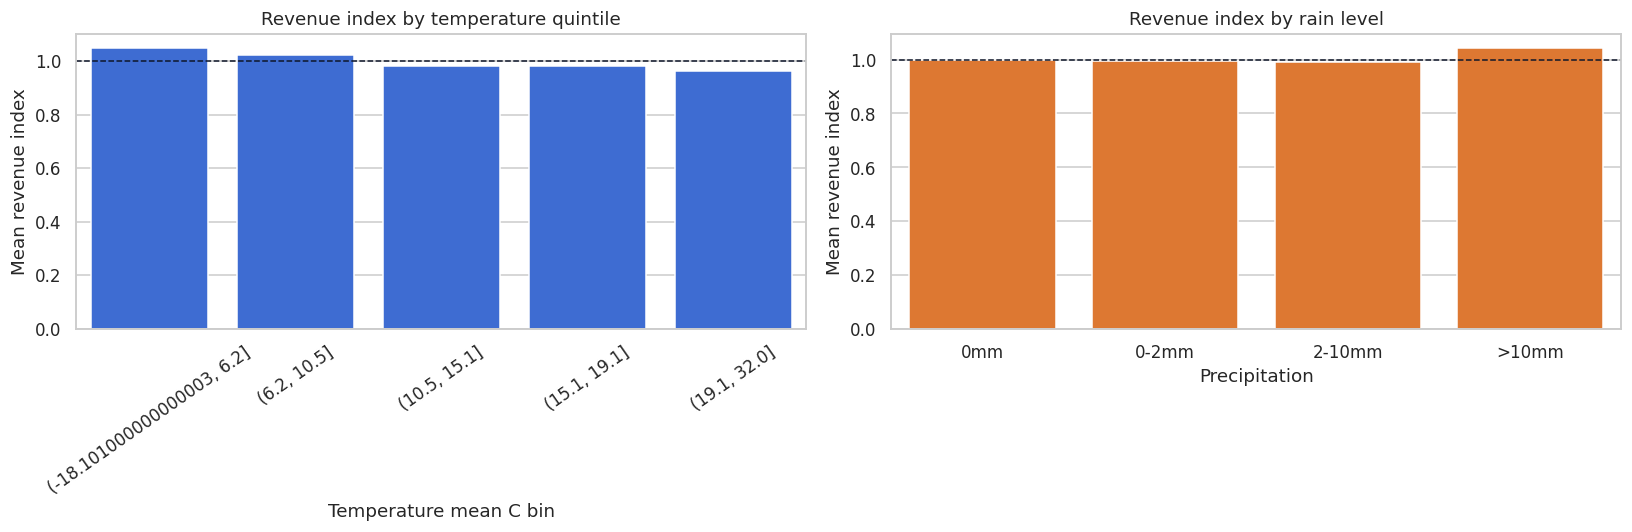

In [8]:
store_type_summary = (
    analysis_df.groupby(["store_type"], as_index=False)
    .agg(stores=("store_id", "nunique"), rows=(TARGET_COL, "size"), total_revenue=(TARGET_COL, "sum"), mean_revenue=(TARGET_COL, "mean"))
    .sort_values("total_revenue", ascending=False)
)

weather_eda = analysis_df.copy()
weather_eda["temp_bin"] = pd.qcut(weather_eda["temperature_mean_c"], q=5, duplicates="drop")
weather_eda["rain_level"] = pd.cut(weather_eda["precipitation_mm"], bins=[-0.001, 0, 2, 10, 1_000], labels=["0mm", "0-2mm", "2-10mm", ">10mm"])

weather_temp_summary = (
    weather_eda.groupby("temp_bin", observed=True)
    .agg(rows=(TARGET_COL, "size"), mean_revenue=(TARGET_COL, "mean"), mean_index=("revenue_index", "mean"))
    .reset_index()
)

weather_rain_summary = (
    weather_eda.groupby("rain_level", observed=True)
    .agg(rows=(TARGET_COL, "size"), mean_revenue=(TARGET_COL, "mean"), mean_index=("revenue_index", "mean"))
    .reset_index()
)

display(store_type_summary.round(3))
display(weather_temp_summary.round(3))
display(weather_rain_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=weather_temp_summary, x="temp_bin", y="mean_index", color=COLOR_MAIN, ax=axes[0])
axes[0].axhline(1.0, color=COLOR_DARK, linestyle="--", linewidth=1)
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_title("Revenue index by temperature quintile")
axes[0].set_xlabel("Temperature mean C bin")
axes[0].set_ylabel("Mean revenue index")

sns.barplot(data=weather_rain_summary, x="rain_level", y="mean_index", color=COLOR_ACCENT, ax=axes[1])
axes[1].axhline(1.0, color=COLOR_DARK, linestyle="--", linewidth=1)
axes[1].set_title("Revenue index by rain level")
axes[1].set_xlabel("Precipitation")
axes[1].set_ylabel("Mean revenue index")
plt.tight_layout()
plt.show()

**Insight weather/store**

Store type phản ánh scale rất rõ: deluxe/gourmet/supermarket có doanh thu cao hơn nhiều so với small grocery. Weather có tín hiệu nhưng không tuyến tính: nhóm nhiệt độ lạnh hơn có revenue index cao hơn một chút, ngày mưa lớn cũng cao hơn trung bình. Dù vậy mức chênh lệch quanh 1.0 cho thấy weather là signal phụ, cần kiểm định và modeling kiểm chứng.

## 8. Kiểm định weekend effect

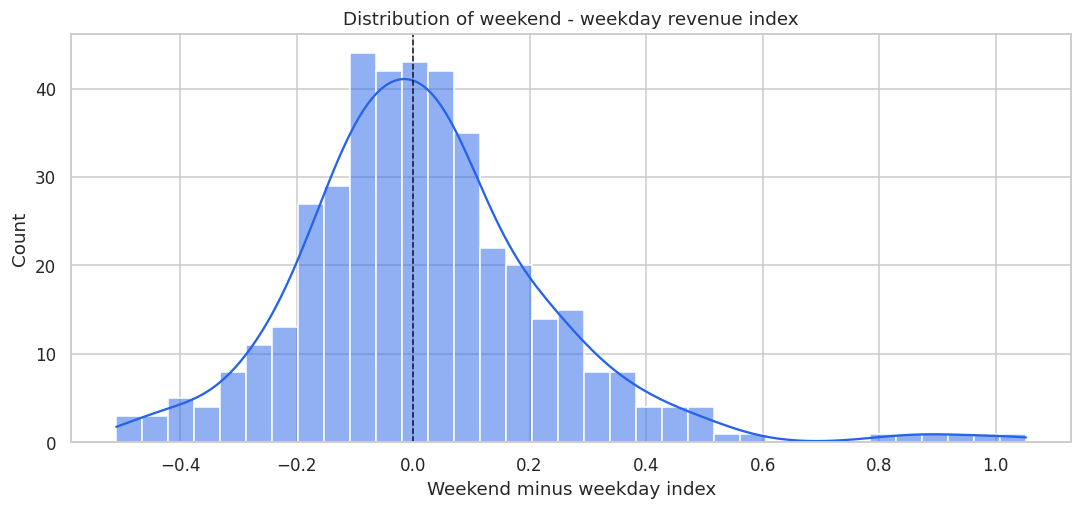

In [22]:
weekend_agg = (
    analysis_df.groupby(["store_id", "product_type", "year", "is_weekend"], as_index=False)
    .agg(mean_revenue=(TARGET_COL, "mean"), mean_index=("revenue_index", "mean"))
)

weekend_pivot = weekend_agg.pivot_table(
    index=["store_id", "product_type", "year"],
    columns="is_weekend",
    values="mean_index",
).dropna()
weekend_pivot.columns = ["weekday_index", "weekend_index"]
weekend_pivot["diff_index"] = weekend_pivot["weekend_index"] - weekend_pivot["weekday_index"]
weekend_pivot["uplift_pct"] = (weekend_pivot["weekend_index"] / weekend_pivot["weekday_index"] - 1) * 100

t_stat, t_pvalue = stats.ttest_rel(weekend_pivot["weekend_index"], weekend_pivot["weekday_index"])
w_stat, w_pvalue = stats.wilcoxon(weekend_pivot["weekend_index"], weekend_pivot["weekday_index"])

weekend_test_summary = pd.DataFrame([
    {"metric": "n_pairs", "value": len(weekend_pivot)},
    {"metric": "weekday_index_mean", "value": weekend_pivot["weekday_index"].mean()},
    {"metric": "weekend_index_mean", "value": weekend_pivot["weekend_index"].mean()},
    {"metric": "mean_diff_index", "value": weekend_pivot["diff_index"].mean()},
    {"metric": "median_uplift_pct", "value": weekend_pivot["uplift_pct"].median()},
    {"metric": "paired_t_pvalue", "value": t_pvalue},
    {"metric": "wilcoxon_pvalue", "value": w_pvalue},
])

weekend_by_product = (
    weekend_pivot.reset_index()
    .groupby("product_type", as_index=False)
    .agg(mean_diff_index=("diff_index", "mean"), median_uplift_pct=("uplift_pct", "median"), n_pairs=("diff_index", "size"))
    .sort_values("mean_diff_index", ascending=False)
)

# display(weekend_test_summary.round(5))
# display(weekend_by_product.round(3))

plt.figure(figsize=(10, 4.8))
sns.histplot(weekend_pivot["diff_index"], bins=35, kde=True, color=COLOR_MAIN)
plt.axvline(0, color=COLOR_DARK, linestyle="--", linewidth=1)
plt.title("Distribution of weekend - weekday revenue index")
plt.xlabel("Weekend minus weekday index")
plt.tight_layout()
plt.show()

**Kết luận kiểm định weekend**

Khác M5, weekend effect ở dataset này **không đủ mạnh sau khi normalize**. Trung bình weekend index chỉ cao hơn weekday khoảng **0.017 điểm index**, median uplift khoảng **1%**, và cả paired t-test lẫn Wilcoxon đều có p-value lớn hơn 0.05. Do đó `is_weekend` vẫn dùng như calendar feature, nhưng không nên xem là giả thuyết business chính.

## 9. Kiểm định weather effect

In [24]:
def kruskal_weather_test(data, group_col, value_col="revenue_index"):
    tmp = data[[group_col, value_col]].dropna().copy()
    grouped = [g[value_col].values for _, g in tmp.groupby(group_col, observed=True) if len(g) >= 20]
    labels = [str(k) for k, g in tmp.groupby(group_col, observed=True) if len(g) >= 20]
    if len(grouped) < 2:
        return None, None
    stat, pvalue = stats.kruskal(*grouped)
    n = sum(len(g) for g in grouped)
    k = len(grouped)
    epsilon_sq = max((stat - k + 1) / (n - k), 0)
    summary = (
        tmp.groupby(group_col, observed=True)
        .agg(rows=(value_col, "size"), mean_index=(value_col, "mean"), median_index=(value_col, "median"))
        .reset_index()
    )
    result = {"group_col": group_col, "groups": k, "n": n, "kruskal_H": stat, "p_value": pvalue, "epsilon_sq": epsilon_sq, "labels": ", ".join(labels)}
    return result, summary

weather_test_df = analysis_df.copy()
weather_test_df["temp_bin"] = pd.qcut(weather_test_df["temperature_mean_c"], q=5, duplicates="drop")
weather_test_df["rain_level"] = pd.cut(weather_test_df["precipitation_mm"], bins=[-0.001, 0, 2, 10, 1_000], labels=["0mm", "0-2mm", "2-10mm", ">10mm"])
weather_test_df["wind_bin"] = pd.qcut(weather_test_df["wind_speed_max_kmh"], q=4, duplicates="drop")

weather_test_rows = []
weather_group_summaries = {}
for col in ["temp_bin", "rain_level", "wind_bin"]:
    result, summary = kruskal_weather_test(weather_test_df, col)
    weather_test_rows.append(result)
    weather_group_summaries[col] = summary

weather_test_results = pd.DataFrame(weather_test_rows)
display(weather_test_results.drop(columns="labels").round(6))

for col, summary in weather_group_summaries.items():
    print(f"\n{col}")
    display(summary.round(4))

,group_col,groups,n,kruskal_H,p_value,epsilon_sq
0,temp_bin,5,22476,86.0268,0.0000,0.0037
1,rain_level,4,22476,20.5390,0.0001,0.0008
2,wind_bin,4,22476,13.8051,0.0032,0.0005



temp_bin


,temp_bin,rows,mean_index,median_index
0,"(-18.101000000000003, 6.2]",4590,1.0492,0.9836
1,"(6.2, 10.5]",4481,1.0240,0.9556
2,"(10.5, 15.1]",4458,0.9800,0.9125
3,"(15.1, 19.1]",4613,0.9824,0.9137
4,"(19.1, 32.0]",4334,0.9624,0.8934



rain_level


,rain_level,rows,mean_index,median_index
0,0mm,13310,0.9981,0.9257
1,0-2mm,3819,0.9955,0.9258
2,2-10mm,3567,0.9898,0.9360
3,>10mm,1780,1.0443,0.9917



wind_bin


,wind_bin,rows,mean_index,median_index
0,"(3.899, 10.1]",5640,0.9825,0.9165
1,"(10.1, 13.3]",5771,1.0091,0.9399
2,"(13.3, 16.6]",5533,0.9925,0.9214
3,"(16.6, 40.0]",5532,1.0158,0.9472


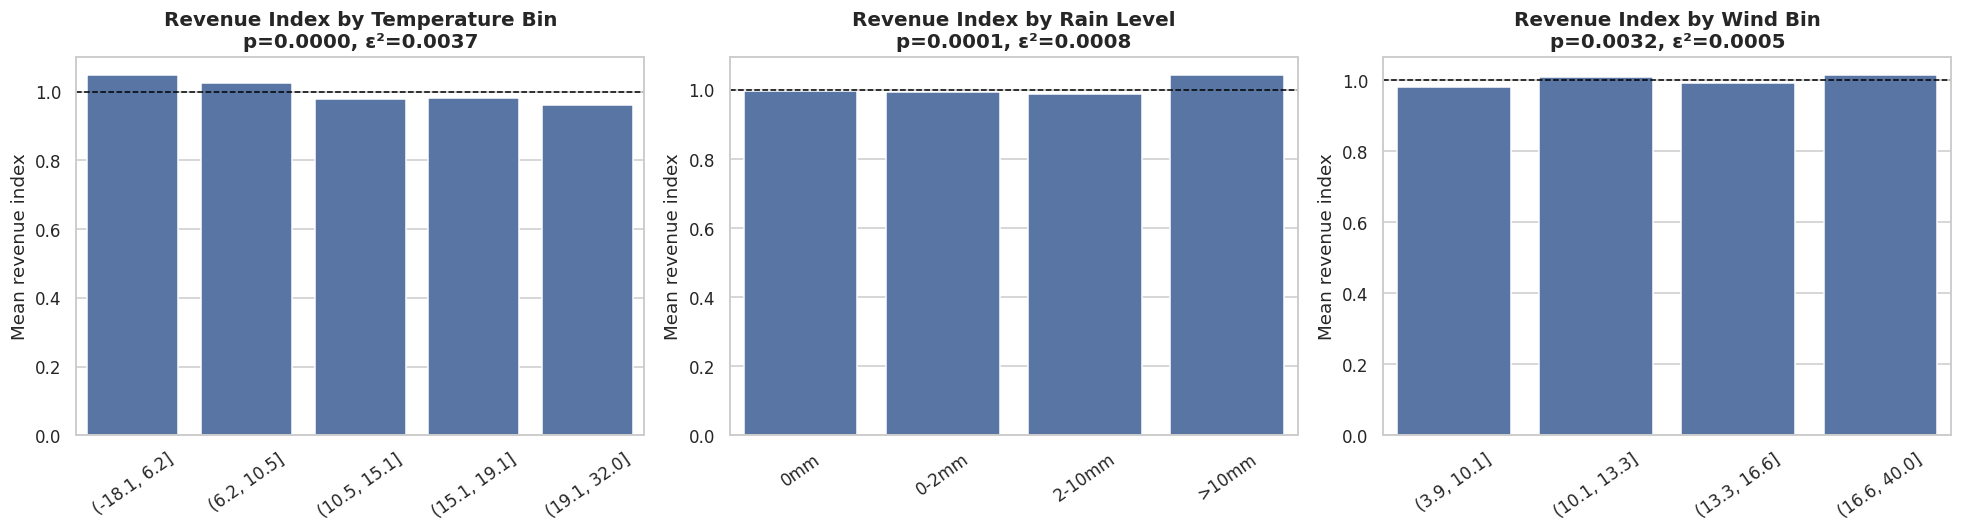

In [25]:
# =========================
# Plot 1: Mean revenue index by weather groups
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style="whitegrid", context="notebook")

def format_group_label(x):
    if isinstance(x, pd.Interval):
        return f"({x.left:.1f}, {x.right:.1f}]"
    return str(x)

test_lookup = weather_test_results.set_index("group_col")

weather_cols = ["temp_bin", "rain_level", "wind_bin"]
titles = {
    "temp_bin": "Revenue Index by Temperature Bin",
    "rain_level": "Revenue Index by Rain Level",
    "wind_bin": "Revenue Index by Wind Bin"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, weather_cols):
    plot_df = weather_group_summaries[col].copy()
    plot_df["group_label"] = plot_df[col].apply(format_group_label)
    
    sns.barplot(
        data=plot_df,
        x="group_label",
        y="mean_index",
        ax=ax
    )
    
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    
    p_value = test_lookup.loc[col, "p_value"]
    epsilon = test_lookup.loc[col, "epsilon_sq"]
    
    ax.set_title(
        f"{titles[col]}\np={p_value:.4f}, ε²={epsilon:.4f}",
        fontsize=13,
        fontweight="bold"
    )
    
    ax.set_xlabel("")
    ax.set_ylabel("Mean revenue index")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

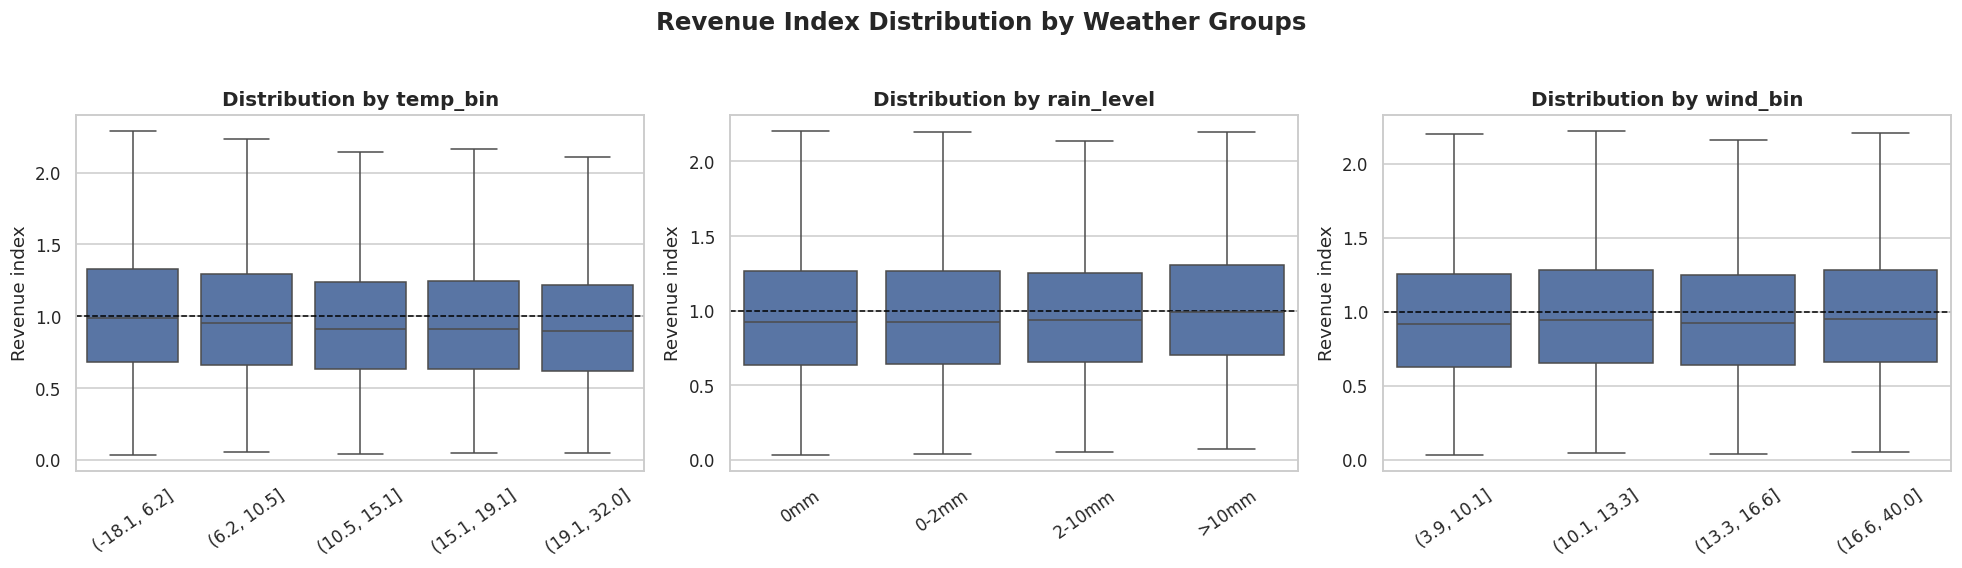

In [26]:
# =========================
# Plot 2: Revenue index distribution by weather groups
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, weather_cols):
    plot_df = weather_test_df[[col, "revenue_index"]].dropna().copy()
    plot_df["group_label"] = plot_df[col].apply(format_group_label)
    
    sns.boxplot(
        data=plot_df,
        x="group_label",
        y="revenue_index",
        showfliers=False,
        ax=ax
    )
    
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
    
    ax.set_title(
        f"Distribution by {col}",
        fontsize=13,
        fontweight="bold"
    )
    
    ax.set_xlabel("")
    ax.set_ylabel("Revenue index")
    ax.tick_params(axis="x", rotation=35)

fig.suptitle(
    "Revenue Index Distribution by Weather Groups",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

**Kết luận kiểm định weather**

Temperature và rain có p-value rất nhỏ, nhưng `epsilon_sq` rất thấp, nghĩa là khác biệt có ý nghĩa thống kê chủ yếu nhờ số dòng lớn chứ effect size nhỏ. Wind không có bằng chứng mạnh. Weather nên được đưa vào mô hình như feature ngoại sinh phụ, không phải biến giải thích chính như lịch sử doanh thu.

## 10. Kiểm định mối quan hệ giữa doanh thu hiện tại và doanh thu quá khứ

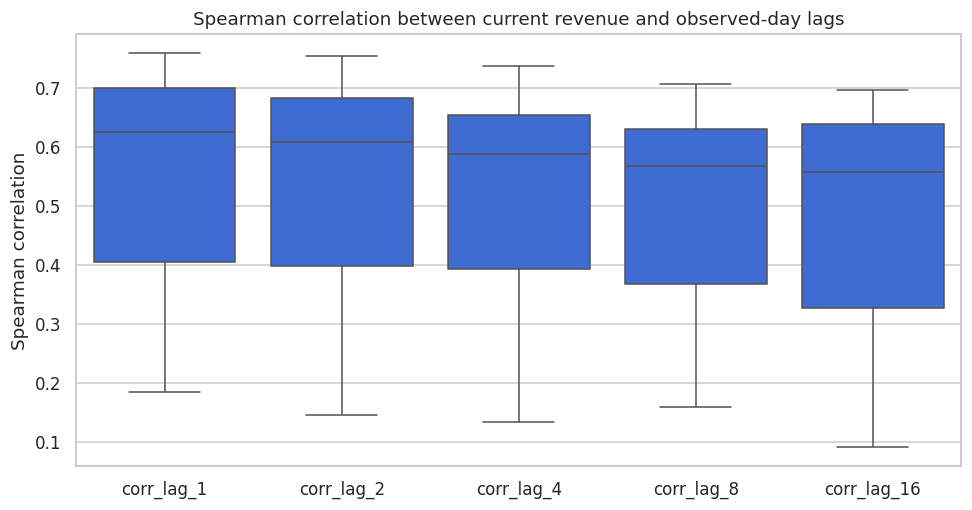

In [33]:
lag_check = analysis_df.sort_values(["store_id", "product_type", "date"]).copy()
lag_group = lag_check.groupby(["store_id", "product_type"], sort=False)[TARGET_COL]
lag_days = [1, 2, 4, 8, 16]

for lag in lag_days:
    lag_check[f"revenue_lag_obs_{lag}"] = lag_group.shift(lag)

lag_corr_rows = []
for product_type, sub in lag_check.groupby("product_type"):
    row = {"product_type": product_type}
    for lag in lag_days:
        tmp = sub[[TARGET_COL, f"revenue_lag_obs_{lag}"]].dropna()
        row[f"corr_lag_{lag}"] = tmp[TARGET_COL].corr(tmp[f"revenue_lag_obs_{lag}"], method="spearman") if len(tmp) >= 20 else np.nan
    lag_corr_rows.append(row)

lag_corr_df = pd.DataFrame(lag_corr_rows)
lag_corr_summary = lag_corr_df.drop(columns="product_type").agg(["mean", "median", "min", "max"]).T.reset_index().rename(columns={"index": "lag"})

# display(lag_corr_summary.round(3))
# display(lag_corr_df.round(3))

plt.figure(figsize=(9, 4.8))
lag_long = lag_corr_df.melt(id_vars="product_type", var_name="lag", value_name="spearman_corr")
sns.boxplot(data=lag_long, x="lag", y="spearman_corr", color=COLOR_MAIN)
plt.title("Spearman correlation between current revenue and observed-day lags")
plt.xlabel("")
plt.ylabel("Spearman correlation")
plt.tight_layout()
plt.show()

**Kết luận lag strength**

Đây là tín hiệu mạnh nhất cho modeling. Median Spearman correlation của các lag quan sát nằm quanh **0.63-0.68**, cao hơn nhiều so với weekend/weather. Các nhóm lớn như `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning`, `Frozen Foods` có autocorrelation cao; các nhóm nhỏ như `Breakfast Foods`, `Pasta & Rice` yếu hơn và khó dự báo hơn.

## 11. Feature engineering không leakage

In [12]:
model_df = analysis_df.sort_values(["store_id", "product_type", "date"]).copy()
model_group = model_df.groupby(["store_id", "product_type"], sort=False)[TARGET_COL]

for lag in [1, 2, 4, 8, 16]:
    model_df[f"revenue_lag_obs_{lag}"] = model_group.shift(lag)

for window in [4, 8, 16]:
    model_df[f"revenue_roll_obs_{window}_mean"] = model_group.transform(lambda s: s.shift(1).rolling(window, min_periods=2).mean())
    model_df[f"revenue_roll_obs_{window}_std"] = model_group.transform(lambda s: s.shift(1).rolling(window, min_periods=2).std())

model_df["date_ordinal"] = (model_df["date"] - model_df["date"].min()).dt.days
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)
model_df["dow_sin"] = np.sin(2 * np.pi * model_df["day_of_week_num"] / 7)
model_df["dow_cos"] = np.cos(2 * np.pi * model_df["day_of_week_num"] / 7)
model_df["is_month_start"] = model_df["date"].dt.is_month_start.astype(int)
model_df["is_month_end"] = model_df["date"].dt.is_month_end.astype(int)

categorical_base = ["store_id", "product_type", "store_type", "store_city", "store_state", "sales_district", "sales_region", "day_of_week"]
categorical_weather = ["weather_code"]

numeric_base = [
    "year", "month", "quarter", "day", "day_of_week_num", "week_of_year", "is_weekend",
    "date_ordinal", "month_sin", "month_cos", "dow_sin", "dow_cos", "is_month_start", "is_month_end",
    "region_id", "total_sqft", "grocery_sqft", "grocery_sqft_ratio", "store_age_years", "years_since_remodel",
]

numeric_weather = [
    "temperature_mean_c", "precipitation_mm", "snowfall_cm", "wind_speed_max_kmh",
    "shortwave_radiation_mj_m2", "is_rainy_day", "is_snowy_day", "is_windy_day",
]

numeric_history = [f"revenue_lag_obs_{lag}" for lag in [1, 2, 4, 8, 16]] + [
    f"revenue_roll_obs_{window}_{stat}" for window in [4, 8, 16] for stat in ["mean", "std"]
]

excluded_from_model = [
    "quantity_sold", "transaction_rows", "unique_products", "unique_brands", "unique_customers",
    "weighted_avg_retail_price", "weighted_avg_product_cost", "weighted_avg_product_weight",
    "avg_revenue_per_customer", "avg_revenue_per_product", "avg_revenue_per_transaction_row",
    "recyclable_share", "low_fat_share",
]

feature_plan = pd.DataFrame([
    {"feature_group": "calendar", "examples": ", ".join(numeric_base[:8]), "leakage_status": "safe"},
    {"feature_group": "store/product identifiers", "examples": ", ".join(categorical_base[:5]), "leakage_status": "safe"},
    {"feature_group": "store metadata", "examples": "total_sqft, grocery_sqft_ratio, store_age_years", "leakage_status": "safe if metadata known"},
    {"feature_group": "weather", "examples": ", ".join(numeric_weather[:4]), "leakage_status": "safe if forecast/actual weather source available"},
    {"feature_group": "history", "examples": ", ".join(numeric_history[:6]), "leakage_status": "safe: all lag/rolling use shift(1)"},
    {"feature_group": "transaction-result fields", "examples": ", ".join(excluded_from_model[:6]), "leakage_status": "excluded"},
])

missing_history = model_df[numeric_history].isna().mean().sort_values(ascending=False).to_frame("missing_pct")

display(feature_plan)
display(missing_history.round(3))
print("Modeling frame shape:", model_df.shape)

,feature_group,examples,leakage_status
0,calendar,"year, month, quarter, day, day_of_week_num, we...",safe
1,store/product identifiers,"store_id, product_type, store_type, store_city...",safe
2,store metadata,"total_sqft, grocery_sqft_ratio, store_age_years",safe if metadata known
3,weather,"temperature_mean_c, precipitation_mm, snowfall...",safe if forecast/actual weather source available
4,history,"revenue_lag_obs_1, revenue_lag_obs_2, revenue_...",safe: all lag/rolling use shift(1)
5,transaction-result fields,"quantity_sold, transaction_rows, unique_produc...",excluded


,missing_pct
revenue_lag_obs_16,0.1480
revenue_lag_obs_8,0.0740
revenue_lag_obs_4,0.0370
revenue_roll_obs_8_mean,0.0190
revenue_lag_obs_2,0.0190
revenue_roll_obs_4_mean,0.0190
revenue_roll_obs_4_std,0.0190
revenue_roll_obs_16_mean,0.0190
revenue_roll_obs_8_std,0.0190
revenue_roll_obs_16_std,0.0190


Modeling frame shape: (22476, 66)


**Feature engineering insight**

Lag/rolling được tạo bằng `shift(1)`, nên mỗi dòng chỉ nhìn thấy doanh thu quá khứ của cùng `store_id × product_type`. Vì store-date của dataset là sampled observed days, tên feature dùng `lag_obs_*`: đây là lag theo lần quan sát trước của cửa hàng, không phải lag đúng 1/7/28 ngày calendar như M5.

## 12. Time-based split

In [13]:
train_end = pd.Timestamp("1998-06-30")
val_end = pd.Timestamp("1998-09-30")

train_df = model_df[model_df["date"] <= train_end].copy()
val_df = model_df[(model_df["date"] > train_end) & (model_df["date"] <= val_end)].copy()
test_df = model_df[model_df["date"] > val_end].copy()
train_val_df = model_df[model_df["date"] <= val_end].copy()

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(train_df), "min_date": train_df["date"].min().date(), "max_date": train_df["date"].max().date(), "revenue_sum": train_df[TARGET_COL].sum()},
    {"split": "validation", "rows": len(val_df), "min_date": val_df["date"].min().date(), "max_date": val_df["date"].max().date(), "revenue_sum": val_df[TARGET_COL].sum()},
    {"split": "test", "rows": len(test_df), "min_date": test_df["date"].min().date(), "max_date": test_df["date"].max().date(), "revenue_sum": test_df[TARGET_COL].sum()},
])

display(split_summary.round(3))

,split,rows,min_date,max_date,revenue_sum
0,train,16814,1997-01-01,1998-06-29,"859,127.6700"
1,validation,2796,1998-07-01,1998-09-30,"145,158.2000"
2,test,2866,1998-10-01,1998-12-30,"173,663.0700"


**Split strategy**

Split theo thời gian mô phỏng forecasting tương lai trên các dòng đã ghi nhận. Train dùng giai đoạn đầu đến cuối tháng 6/1998, validation là quý 3/1998, test là quý 4/1998. Vì không tạo full panel, số dòng mỗi split phản ánh số giao dịch/nhóm sản phẩm thực tế được ghi nhận trong từng giai đoạn.

## 13. Baseline models

In [14]:
def make_mean_baseline_predictions(train_frame, pred_frame):
    global_mean = train_frame[TARGET_COL].mean()
    product_mean = train_frame.groupby("product_type")[TARGET_COL].mean()
    store_product_mean = train_frame.groupby(["store_id", "product_type"])[TARGET_COL].mean()

    pred_product_mean = pred_frame["product_type"].map(product_mean).fillna(global_mean)

    key_df = pred_frame[["store_id", "product_type"]].copy()
    key_df["store_product_mean"] = [store_product_mean.get((sid, pt), np.nan) for sid, pt in zip(key_df["store_id"], key_df["product_type"])]
    pred_store_product_mean = key_df["store_product_mean"].fillna(pred_product_mean).fillna(global_mean)

    return {
        "global_mean": np.full(len(pred_frame), global_mean),
        "product_type_mean": pred_product_mean.values,
        "store_product_mean": pred_store_product_mean.values,
        "lag_obs_1": pred_frame["revenue_lag_obs_1"].fillna(pred_product_mean).fillna(global_mean).values,
        "roll_obs_4_mean": pred_frame["revenue_roll_obs_4_mean"].fillna(pred_frame["revenue_lag_obs_1"]).fillna(pred_product_mean).fillna(global_mean).values,
    }

baseline_rows = []
for model_name, pred in make_mean_baseline_predictions(train_df, val_df).items():
    baseline_rows.append(regression_metrics(model_name, "validation", val_df[TARGET_COL], pred))

for model_name, pred in make_mean_baseline_predictions(train_val_df, test_df).items():
    baseline_rows.append(regression_metrics(model_name, "test", test_df[TARGET_COL], pred))

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results.round(4))

,model,split,rows,MAE,RMSE,WAPE,sMAPE,R2,bias,actual_sum,pred_sum
0,global_mean,validation,2796,38.2673,48.9657,0.7371,0.8161,-0.0003,-0.8204,"145,158.2000","142,864.3372"
1,product_type_mean,validation,2796,28.6428,39.7955,0.5517,0.6449,0.3393,-0.7624,"145,158.2000","143,026.6601"
2,store_product_mean,validation,2796,16.0290,23.5886,0.3087,0.4123,0.7679,-0.7261,"145,158.2000","143,127.9734"
3,lag_obs_1,validation,2796,21.4335,31.4418,0.4128,0.5454,0.5876,-0.2290,"145,158.2000","144,517.8400"
4,roll_obs_4_mean,validation,2796,17.6877,25.8117,0.3407,0.4488,0.7220,-0.1525,"145,158.2000","144,731.7175"
5,global_mean,test,2866,43.2715,57.7805,0.7141,0.8098,-0.0271,-9.3813,"173,663.0700","146,776.3031"
6,product_type_mean,test,2866,34.2261,46.9260,0.5648,0.6700,0.3226,-9.7960,"173,663.0700","145,587.7349"
7,store_product_mean,test,2866,19.6895,30.2332,0.3249,0.4187,0.7188,-10.2802,"173,663.0700","144,199.9812"
8,lag_obs_1,test,2866,23.1835,33.8774,0.3826,0.5112,0.6469,-0.5685,"173,663.0700","172,033.7000"
9,roll_obs_4_mean,test,2866,18.8550,28.0166,0.3112,0.4180,0.7585,-1.9287,"173,663.0700","168,135.5275"


**Baseline insight**

`store_product_mean` đã rất mạnh vì baseline riêng của từng cửa hàng và nhóm sản phẩm giải thích phần lớn scale doanh thu. Các baseline lịch sử như `roll_obs_4_mean` cải thiện thêm, đặc biệt trên test. Điều này xác nhận insight từ lag strength: lịch sử bán hàng là nhóm feature quan trọng nhất.

## 14. LightGBM model và ablation

In [15]:
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

feature_sets = {
    "calendar_store_product": {
        "categorical": categorical_base,
        "numeric": numeric_base,
    },
    "+weather": {
        "categorical": categorical_base + categorical_weather,
        "numeric": numeric_base + numeric_weather,
    },
    "+history": {
        "categorical": categorical_base,
        "numeric": numeric_base + numeric_history,
    },
    "+history_weather": {
        "categorical": categorical_base + categorical_weather,
        "numeric": numeric_base + numeric_weather + numeric_history,
    },
}


def build_lightgbm_pipeline(categorical_features, numeric_features):
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), numeric_features),
            (
                "cat",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
                ]),
                categorical_features,
            ),
        ]
    )

    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.90,
        min_child_samples=20,
        random_state=42,
        verbose=-1,
    )

    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


def fit_predict_lgbm(train_frame, pred_frame, categorical_features, numeric_features):
    feature_cols = categorical_features + numeric_features
    pipeline = build_lightgbm_pipeline(categorical_features, numeric_features)
    pipeline.fit(train_frame[feature_cols], train_frame[TARGET_COL])
    pred = np.clip(pipeline.predict(pred_frame[feature_cols]), 0, None)
    return pipeline, pred

ablation_rows = []
models = {}
predictions = {}

for model_name, spec in feature_sets.items():
    cat_features = spec["categorical"]
    num_features = spec["numeric"]
    feature_cols = cat_features + num_features

    val_model, val_pred = fit_predict_lgbm(train_df, val_df, cat_features, num_features)
    final_model, test_pred_values = fit_predict_lgbm(train_val_df, test_df, cat_features, num_features)

    ablation_rows.append(regression_metrics(model_name, "validation", val_df[TARGET_COL], val_pred))
    ablation_rows.append(regression_metrics(model_name, "test", test_df[TARGET_COL], test_pred_values))

    models[model_name] = {
        "validation_model": val_model,
        "test_model": final_model,
        "categorical_features": cat_features,
        "numeric_features": num_features,
        "feature_cols": feature_cols,
    }
    predictions[(model_name, "validation")] = val_pred
    predictions[(model_name, "test")] = test_pred_values

ablation_results = pd.DataFrame(ablation_rows)
display(ablation_results.round(4))

selected_model_name = "+history_weather"
primary_test_pred = predictions[(selected_model_name, "test")]
print(f"Selected final model for error analysis: {selected_model_name}")

,model,split,rows,MAE,RMSE,WAPE,sMAPE,R2,bias,actual_sum,pred_sum
0,calendar_store_product,validation,2796,16.5577,24.2457,0.3189,0.4311,0.7548,-2.0828,"145,158.2000","139,334.7453"
1,calendar_store_product,test,2866,18.9156,27.7095,0.3122,0.4252,0.7638,-1.8912,"173,663.0700","168,243.0287"
2,+weather,validation,2796,16.2651,23.8214,0.3133,0.4197,0.7633,-1.1035,"145,158.2000","142,072.9144"
3,+weather,test,2866,18.6371,28.2383,0.3076,0.4048,0.7547,-6.0314,"173,663.0700","156,377.1976"
4,+history,validation,2796,16.8477,24.9135,0.3245,0.4248,0.7411,-2.5074,"145,158.2000","138,147.5934"
5,+history,test,2866,18.1576,26.6908,0.2997,0.4039,0.7808,-0.4728,"173,663.0700","172,308.0671"
6,+history_weather,validation,2796,16.5424,24.4275,0.3186,0.4201,0.7511,-1.9308,"145,158.2000","139,759.5631"
7,+history_weather,test,2866,17.8441,26.5256,0.2945,0.3958,0.7835,-2.0885,"173,663.0700","167,677.3892"


Selected final model for error analysis: +history_weather


**Modeling insight**

`store_product_mean` là baseline rất mạnh và trên validation còn cạnh tranh trực tiếp với LightGBM. Điểm đáng chú ý là trên test cuối năm, model `+history_weather` đạt **WAPE 29.51%** trên các dòng observed-only, tốt hơn các baseline lịch sử đơn giản như `roll_obs_4_mean` (**WAPE 31.12%**). Weather cải thiện validation nhẹ nhưng không ổn định nếu đứng một mình; model chính vẫn cần dựa vào store/product/calendar và lịch sử doanh thu quá khứ, không dùng transaction-result leakage.

## 15. Error analysis trên test set

,model,split,rows,MAE,RMSE,WAPE,sMAPE,R2,bias,actual_sum,pred_sum
0,+history_weather,test,2866,17.8441,26.5256,0.2945,0.3958,0.7835,-2.0885,"173,663.0700","167,677.3892"


,product_type,rows,actual_revenue,pred_revenue,mae,bias,wape,actual_share_pct
3,Breakfast Foods,141,"2,268.0800","2,013.9540",8.5690,-1.8020,0.5330,1.3060
12,Pasta & Rice,156,"3,442.5500","3,493.2710",10.8730,0.3250,0.4930,1.9820
9,Magazines & Miscellaneous,160,"3,722.0200","3,686.7320",10.7690,-0.2210,0.4630,2.1430
1,Bakery,177,"5,414.8700","5,489.5040",13.6540,0.4220,0.4460,3.1180
0,Alcohol,169,"4,562.1600","4,389.2070",11.2720,-1.0230,0.4180,2.6270
14,Seafood,172,"4,862.6400","4,890.9560",11.1260,0.1650,0.3940,2.8000
5,Dairy & Eggs,191,"13,460.9100","13,452.6210",22.8520,-0.0430,0.3240,7.7510
10,Meat & Deli,183,"9,506.5600","9,848.6580",16.6100,1.8690,0.3200,5.4740
7,Health & Personal Care,184,"9,082.5100","9,269.3200",15.2110,1.0150,0.3080,5.2300
4,Canned & Soup,184,"8,955.6900","8,995.1890",14.3510,0.2150,0.2950,5.1570


,store_id,store_city,store_state,rows,actual_revenue,pred_revenue,mae,bias,wape,actual_share_pct
0,2,Bellingham,WA,164,"1,449.3700","1,306.8720",4.5240,-0.8690,0.5120,0.8350
6,14,San Francisco,CA,177,"1,578.7600","1,142.2450",4.4400,-2.4660,0.4980,0.9090
10,22,Walla Walla,WA,174,"1,404.1900","1,379.1440",3.8770,-0.1440,0.4800,0.8090
11,23,Yakima,WA,216,"6,020.0500","5,998.2350",12.6540,-0.1010,0.4540,3.4670
2,6,Beverly Hills,CA,234,"14,979.6000","16,429.2430",21.6620,6.1950,0.3380,8.6260
4,11,Portland,OR,240,"17,444.6700","17,308.2390",21.8840,-0.5680,0.3010,10.0450
12,24,San Diego,CA,237,"16,304.8200","15,835.4570",20.2650,-1.9800,0.2950,9.3890
3,7,Los Angeles,CA,237,"17,639.0400","15,665.3350",21.7550,-8.3280,0.2920,10.1570
7,15,Seattle,WA,237,"19,869.2500","17,021.8680",23.4050,-12.0140,0.2790,11.4410
1,3,Bremerton,WA,237,"17,276.7800","15,671.1530",20.2630,-6.7750,0.2780,9.9480


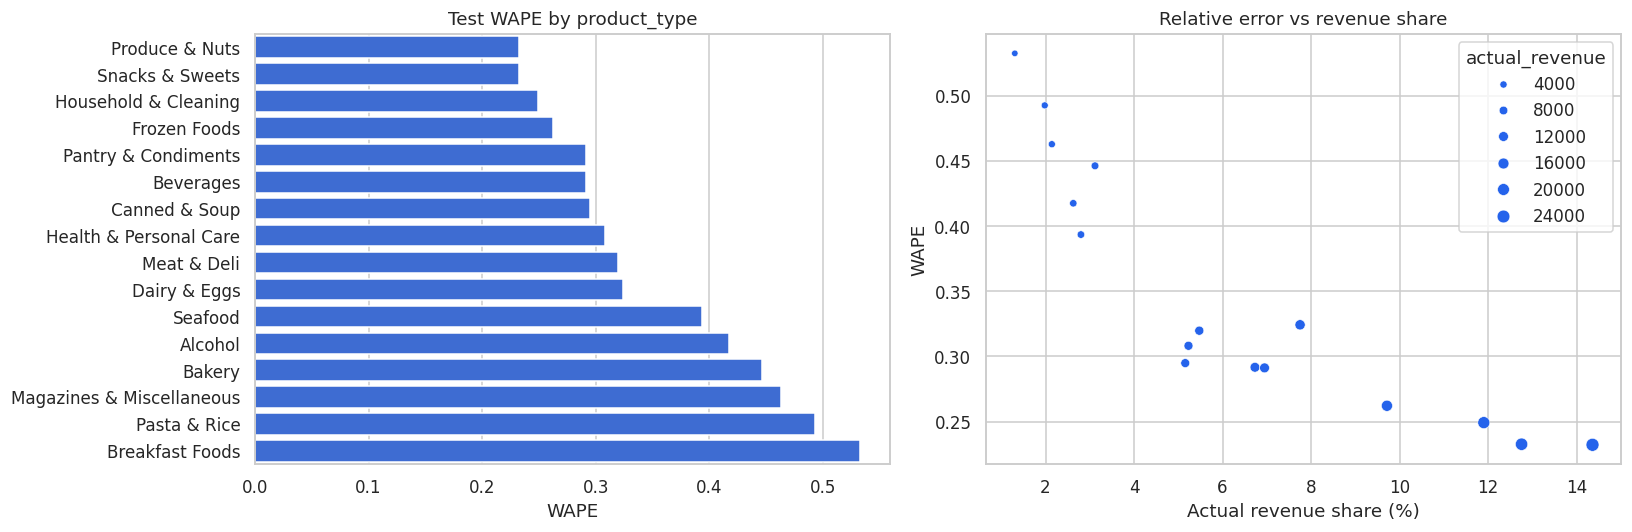

In [16]:
test_pred = test_df[["date", "store_id", "store_city", "store_state", "product_type", TARGET_COL, "day_of_week", "month"]].copy()
test_pred["pred_revenue"] = primary_test_pred
test_pred["error"] = test_pred["pred_revenue"] - test_pred[TARGET_COL]
test_pred["abs_error"] = test_pred["error"].abs()

def grouped_error(data, group_cols):
    out = (
        data.groupby(group_cols)
        .agg(
            rows=(TARGET_COL, "size"),
            actual_revenue=(TARGET_COL, "sum"),
            pred_revenue=("pred_revenue", "sum"),
            mae=("abs_error", "mean"),
            bias=("error", "mean"),
        )
        .reset_index()
    )
    out["wape"] = out["mae"] * out["rows"] / out["actual_revenue"].replace(0, np.nan)
    out["actual_share_pct"] = out["actual_revenue"] / out["actual_revenue"].sum() * 100
    return out

error_by_product = grouped_error(test_pred, ["product_type"]).sort_values("wape", ascending=False)
error_by_store = grouped_error(test_pred, ["store_id", "store_city", "store_state"]).sort_values("wape", ascending=False)

selected_test_metrics = regression_metrics(selected_model_name, "test", test_df[TARGET_COL], primary_test_pred)

display(pd.DataFrame([selected_test_metrics]).round(4))
display(error_by_product.round(3))
display(error_by_store.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_product = error_by_product.sort_values("wape", ascending=True)
sns.barplot(data=plot_product, y="product_type", x="wape", color=COLOR_MAIN, ax=axes[0])
axes[0].set_title("Test WAPE by product_type")
axes[0].set_xlabel("WAPE")
axes[0].set_ylabel("")

sns.scatterplot(data=error_by_product, x="actual_share_pct", y="wape", size="actual_revenue", color=COLOR_MAIN, ax=axes[1])
axes[1].set_title("Relative error vs revenue share")
axes[1].set_xlabel("Actual revenue share (%)")
axes[1].set_ylabel("WAPE")
plt.tight_layout()
plt.show()

**Error insight**

Sai số tương đối thường cao hơn ở nhóm doanh thu nền thấp như `Breakfast Foods`, `Pasta & Rice`, `Magazines & Miscellaneous`. Các nhóm lớn như `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning` có MAE lớn hơn về tiền tuyệt đối nhưng WAPE thường thấp hơn. Đây là pattern quen thuộc trong retail forecasting: model tổng thể dễ tối ưu nhóm volume lớn hơn nhóm long-tail.

## 16. LightGBM feature importance

,feature,importance
0,num__revenue_lag_obs_1,884
1,num__wind_speed_max_kmh,822
2,num__revenue_lag_obs_8,776
3,num__revenue_roll_obs_16_mean,772
4,num__shortwave_radiation_mj_m2,729
5,num__revenue_roll_obs_4_std,727
6,num__revenue_lag_obs_2,724
7,num__revenue_lag_obs_4,711
8,num__revenue_lag_obs_16,676
9,num__temperature_mean_c,599


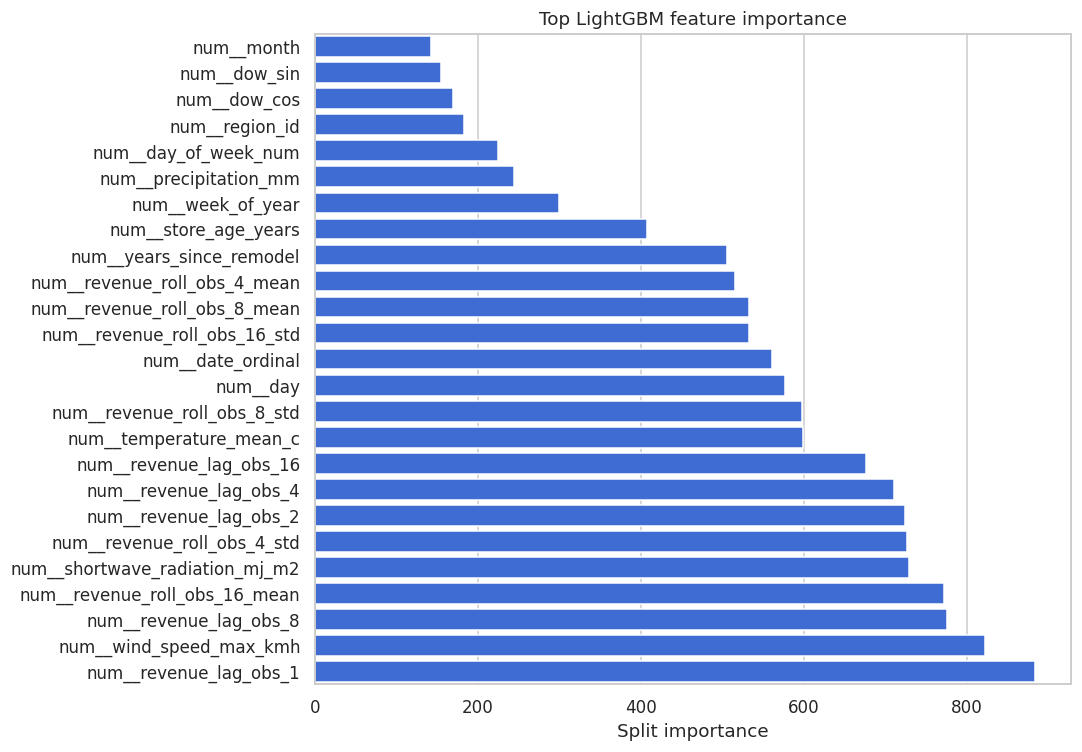

In [17]:
selected_pipeline = models[selected_model_name]["test_model"]
preprocessor = selected_pipeline.named_steps["preprocessor"]
lgbm_model = selected_pipeline.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
importance = (
    pd.DataFrame({"feature": feature_names, "importance": lgbm_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance.head(30))

plt.figure(figsize=(10, 7))
plot_importance = importance.head(25).sort_values("importance", ascending=True)
sns.barplot(data=plot_importance, y="feature", x="importance", color=COLOR_MAIN)
plt.title("Top LightGBM feature importance")
plt.xlabel("Split importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Interpretation caution**

Feature importance không phải causal effect. Nó cho biết biến nào hữu ích cho split của cây. Nếu rolling/lag, `product_type`, `store` metadata, calendar và weather cùng xuất hiện, điều đó phù hợp với EDA: scale store-product và history là nền chính, weather/calendar chỉ bổ sung tín hiệu phụ.

## 18. Kết luận tổng hợp

1. Dataset gốc là dữ liệu đã aggregate ở mức `date × store_id × product_type`; notebook hiện tại **chỉ dùng các dòng được ghi nhận**, không tạo thêm dòng ngoài file gốc.
2. Target là `revenue`. Các biến như `quantity_sold`, `transaction_rows`, `unique_customers`, `weighted_avg_*`, `avg_revenue_per_*` có rủi ro leakage nên không dùng trong clean forecasting model.
3. Doanh thu tập trung ở các product type lớn: `Produce & Nuts`, `Snacks & Sweets`, `Household & Cleaning`, và ở các store lớn như Salem/Tacoma.
4. Weekend/weather là tín hiệu phụ; tín hiệu quan trọng nhất vẫn là baseline và history của cùng `store_id × product_type`.
5. Model chính `LightGBM + history + weather` trên test observed-only đạt **MAE 17.88**, **WAPE 29.51%**, **R² 0.783**.
6. Vì chỉ dùng observed rows, kết quả mô hình trả lời câu hỏi: **nếu một nhóm sản phẩm được ghi nhận trong store-date, doanh thu của nhóm đó là bao nhiêu?** Notebook không cố dự báo trường hợp product type không xuất hiện trong ngày.
7. Với bài toán dự báo doanh thu theo nhóm sản phẩm dựa trên giao dịch ghi nhận, cần đánh giá thêm theo từng `product_type` để tránh nhóm volume lớn che khuất sai số của nhóm long-tail.